# Icescopy freeze-count output to INP/L air with UFOLAF

This notebook keeps the workflow explicit:

1. `ufolaf.read_counts(...)` applies the cycle policy and returns table(s) split by sample/dilution, or a cycle-keyed dict when cycles are preserved.
2. `ufolaf.fraction_frozen(...)` reduces each count table to a temperature-threshold frozen-fraction table while preserving the read shape.
3. `ufolaf.cumulative_spec(...)` calculates per-dilution K(T), still as separate tables.
4. `ufolaf.cumulative_spec_stitch(...)` and `ufolaf.cumulative_spec_mle(...)` merge the dilution series into one spectrum.
5. `ufolaf.normalize_spec(...)` converts INP/mL suspension to INP/L air.

In [1]:
from pathlib import Path
import os
import sys
import inspect

os.environ.setdefault("MPLCONFIGDIR", "/tmp/ufolaf_matplotlib")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp/ufolaf_cache")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

UFOLAF_ROOT = Path("/Users/C832577250/Project/UFOLAF")
UFOLAF_SRC = str(UFOLAF_ROOT / "src")
if UFOLAF_SRC in sys.path:
    sys.path.remove(UFOLAF_SRC)
sys.path.insert(0, UFOLAF_SRC)

for module_name in list(sys.modules):
    if module_name == "ufolaf" or module_name.startswith("ufolaf_"):
        del sys.modules[module_name]

import ufolaf

print(f"UFOLAF module: {ufolaf.__file__}")
print(f"MLE API: {inspect.signature(ufolaf.cumulative_spec_mle)}")

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.max_columns = 120

DATA_PATH = Path("/Volumes/Hailstone Data/demo (M1) 08.12.25 base rerun/freeze_count_timeseries.csv")
OLAF_REFERENCE_PATH = Path("/Volumes/Hailstone Data/Mentor data from Carson/(M1) 08.12.25 base rerun/INPs_L_frozen_at_temp_reviewed_crg m1 08.12.25 base rerun.csv")

TEMPERATURE_STEP_C = 0.5
TEMPERATURE_METHOD = "max"
TEMPERATURE_TOLERANCE_C = 0.01
CYCLE_POLICY = "single"
ENFORCE_MONOTONE = True
TEMPERATURE_XLIM = (-30, 0)

MLE_TEMPERATURE_ELIGIBILITY_C = {
    1: 99.0,
    13: -10.0,
    169: -15.0,
    2197: -20.0,
    28561: -25.0,
}
DILUTION_ACTION_COUNTS = {
    1: 0,
    13: 1,
    169: 2,
    2197: 3,
    28561: 4,
}
ACTION_WEIGHT_HALF_LIFE = 15
DILUTION_LIKELIHOOD_WEIGHTS = {
    dilution: float(np.exp(-np.log(2.0) * actions / ACTION_WEIGHT_HALF_LIFE))
    for dilution, actions in DILUTION_ACTION_COUNTS.items()
}

def sample_dilution_lookup(tables):
    """Return {sample_id: dilution} from table metadata."""
    if isinstance(tables, dict):
        table_iterable = tables.values()
    elif isinstance(tables, (list, tuple)):
        table_iterable = tables
    else:
        table_iterable = (tables,)

    lookup = {}
    for table in table_iterable:
        metadata = getattr(table, "metadata", None)
        if isinstance(metadata, dict):
            metadata_iterable = metadata.values()
        elif metadata is None:
            metadata_iterable = ()
        else:
            metadata_iterable = (metadata,)

        for sample_metadata in metadata_iterable:
            sample_id = getattr(sample_metadata, "sample_id", None)
            dilution = getattr(sample_metadata, "dilution", None)
            if sample_id is not None and dilution is not None:
                lookup[str(sample_id)] = float(dilution)
    return lookup


def cutoff_for_dilution(dilution):
    """Return the warmest eligible MLE temperature for a dilution."""
    if dilution is None:
        return None
    for cutoff_dilution, cutoff in MLE_TEMPERATURE_ELIGIBILITY_C.items():
        try:
            dilution_match = np.isclose(float(dilution), float(cutoff_dilution), rtol=0, atol=1e-9)
            cutoff_value = float(cutoff)
        except (TypeError, ValueError):
            continue
        if dilution_match and np.isfinite(cutoff_value):
            return cutoff_value
    return None


def plot_dilution_with_cutoff_style(
    ax,
    plot_df,
    *,
    sample_id,
    dilution_by_sample_id,
    marker="o",
    color=None,
    ms=3,
    lw=1.0,
    alpha=0.65,
    label=None,
    zorder=1,
):
    """Plot a dilution curve with excluded warm-side MLE temperatures dotted."""
    cutoff = cutoff_for_dilution(dilution_by_sample_id.get(str(sample_id)))
    if cutoff is None:
        ax.plot(
            plot_df["temperature_C"],
            plot_df["value"],
            marker=marker,
            ms=ms,
            lw=lw,
            alpha=alpha,
            color=color,
            label=label,
            zorder=zorder,
        )
        return

    eligible = plot_df["temperature_C"] <= cutoff
    if bool(eligible.all()):
        ax.plot(
            plot_df["temperature_C"],
            plot_df["value"],
            marker=marker,
            ms=ms,
            lw=lw,
            alpha=alpha,
            color=color,
            label=label,
            zorder=zorder,
        )
        return

    excluded_label = label if not bool(eligible.any()) else None
    line, = ax.plot(
        plot_df["temperature_C"],
        plot_df["value"],
        marker=marker,
        ms=ms,
        lw=lw,
        alpha=min(alpha, 0.28),
        color=color,
        linestyle=":",
        label=excluded_label,
        zorder=zorder,
    )
    line_color = line.get_color()

    if bool(eligible.any()):
        eligible_df = plot_df.loc[eligible]
        ax.plot(
            eligible_df["temperature_C"],
            eligible_df["value"],
            marker=marker,
            ms=ms,
            lw=lw,
            alpha=alpha,
            color=line_color,
            linestyle="-",
            label=label,
            zorder=zorder,
        )



UFOLAF module: /Users/C832577250/Project/UFOLAF/src/ufolaf.py
MLE API: (table: 'TemperatureFrozenFractionTable | TableSequence | TableMapping', metadata_by_sample_id: 'dict[str, SampleMetadata] | None' = None, *, sample_group_by: "Literal['sample_id', 'sample_name', 'sample_long_name'] | dict[str, str] | None" = None, enforce_monotone: 'bool' = False, confidence_drop: 'float' = 1.920729410347062, temperature_eligibility_C: 'Mapping[Any, float] | None' = None, dilution_likelihood_weights: 'Mapping[Any, float] | None' = None, dilution_action_counts: 'Mapping[Any, float] | None' = None, action_weight_lambda: 'float | None' = None, action_weight_half_life: 'float | None' = None) -> 'CumulativeNucleusSpectrumTable | dict[str, Any]'


## Read Counts

`read_counts` applies `CYCLE_POLICY`. For `single` and `pooled`, it returns one table or a list of sample/dilution tables. For `preserve`, it returns a cycle-keyed dictionary whose values are one table or a dilution-list.

In [2]:
count_tables = ufolaf.read_counts(DATA_PATH, cycle_policy=CYCLE_POLICY)
raw_counts = ufolaf.tables_to_dataframe(count_tables)

print(f"Sample/dilution groups: {raw_counts['sample_id'].nunique()}")
print(f"Raw count rows: {len(raw_counts):,}")
display(ufolaf.metadata_frame(count_tables))
display(raw_counts.head())

Sample/dilution groups: 5
Raw count rows: 44,405


,sample_id,sample_name,sample_long_name,sample_type,dilution,well_volume_uL,air_volume_L,filter_fraction_used,suspension_volume_mL,dry_mass_g
0,Sample_0,Sample_0,CRG_M1_1,air,1.0,50.0,17829.1,1.0,10.0,None
1,Sample_1,Sample_1,CRG_M1_13,air,13.0,50.0,17829.1,1.0,10.0,None
2,Sample_2,Sample_2,CRG_M1_169,air,169.0,50.0,17829.1,1.0,10.0,None
3,Sample_3,Sample_3,CRG_M1_2197,air,2197.0,50.0,17829.1,1.0,10.0,None
4,Sample_4,Sample_4,CRG_M1_28561,air,28561.0,50.0,17829.1,1.0,10.0,None


,sample_id,temperature_C,n_total,n_frozen,fraction_frozen,time_s,cycle,observation_id
0,Sample_0,20.634,32.0,0.0,0.0,0.00,0,NaN
1,Sample_0,20.632,32.0,0.0,0.0,0.34,0,NaN
2,Sample_0,20.634,32.0,0.0,0.0,1.27,0,NaN
3,Sample_0,20.615,32.0,0.0,0.0,2.27,0,NaN
4,Sample_0,20.610,32.0,0.0,0.0,3.27,0,NaN


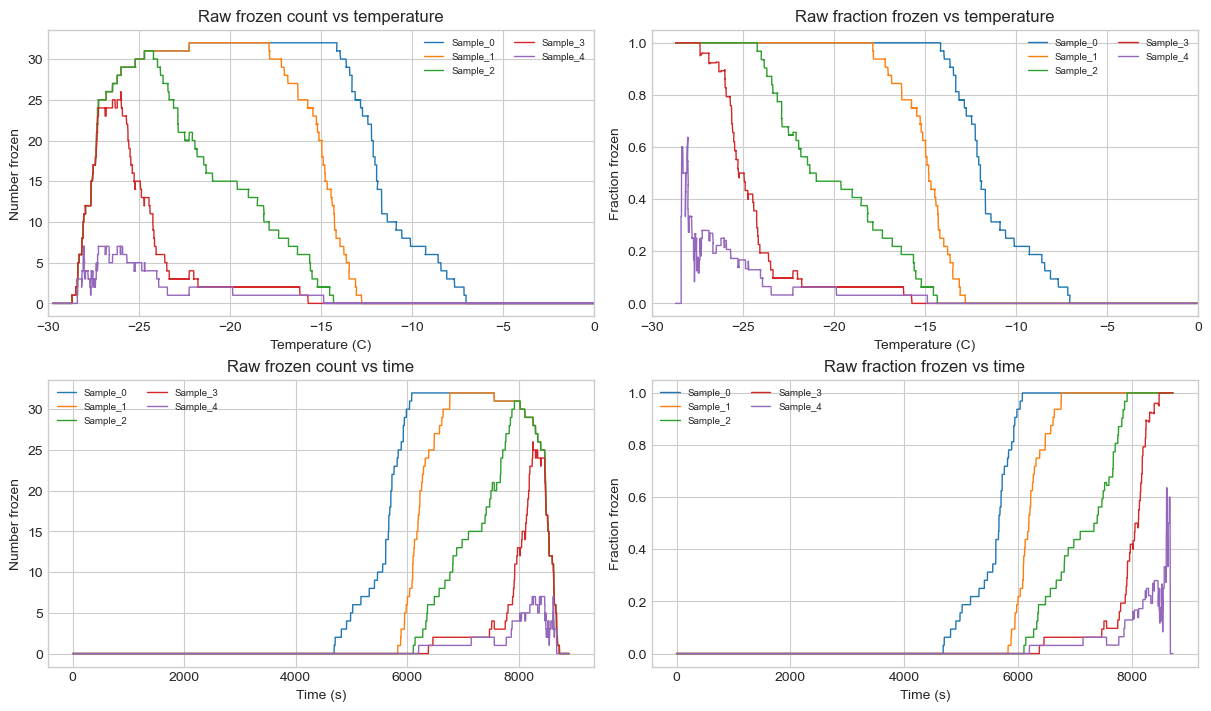

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)

for sample_id, sample_df in raw_counts.groupby("sample_id", sort=False):
    axes[0, 0].plot(sample_df["temperature_C"], sample_df["n_frozen"], lw=1.0, label=sample_id)
    axes[0, 1].plot(sample_df["temperature_C"], sample_df["fraction_frozen"], lw=1.0, label=sample_id)
    if "time_s" in sample_df:
        axes[1, 0].plot(sample_df["time_s"], sample_df["n_frozen"], lw=1.0, label=sample_id)
        axes[1, 1].plot(sample_df["time_s"], sample_df["fraction_frozen"], lw=1.0, label=sample_id)

axes[0, 0].set(title="Raw frozen count vs temperature", xlabel="Temperature (C)", ylabel="Number frozen", xlim=TEMPERATURE_XLIM)
axes[0, 1].set(title="Raw fraction frozen vs temperature", xlabel="Temperature (C)", ylabel="Fraction frozen", xlim=TEMPERATURE_XLIM)
axes[1, 0].set(title="Raw frozen count vs time", xlabel="Time (s)", ylabel="Number frozen")
axes[1, 1].set(title="Raw fraction frozen vs time", xlabel="Time (s)", ylabel="Fraction frozen")

for ax in axes.ravel():
    ax.legend(fontsize=7, ncols=2)

plt.show()

## Reduce To Temperature-Threshold Fraction Frozen

`TEMPERATURE_METHOD = "max"` means each threshold uses all observations at or warmer than that threshold, with `TEMPERATURE_TOLERANCE_C` slack, and keeps the paired count row with the highest fraction frozen. It is not a centered bin average.

In [4]:
fraction_tables = ufolaf.fraction_frozen(
    count_tables,
    step_C=TEMPERATURE_STEP_C,
    method=TEMPERATURE_METHOD,
    temperature_tolerance_C=TEMPERATURE_TOLERANCE_C,
)
fraction_df = ufolaf.tables_to_dataframe(fraction_tables)

print(f"Fraction sample/dilution groups: {fraction_df['sample_id'].nunique()}")
display(fraction_df.head())

Fraction sample/dilution groups: 5


,sample_id,temperature_C,temperature_bin_width_C,temperature_bin_method,temperature_bin_left_C,temperature_bin_right_C,n_total,n_frozen,fraction_frozen,obs_count
0,Sample_0,20.5,0.5,cold_threshold_max_tol_0.01C,20.5,21.0,32.0,0.0,0.0,179
1,Sample_0,20.0,0.5,cold_threshold_max_tol_0.01C,20.0,20.5,32.0,0.0,0.0,147
2,Sample_0,19.5,0.5,cold_threshold_max_tol_0.01C,19.5,20.0,32.0,0.0,0.0,83
3,Sample_0,19.0,0.5,cold_threshold_max_tol_0.01C,19.0,19.5,32.0,0.0,0.0,66
4,Sample_0,18.5,0.5,cold_threshold_max_tol_0.01C,18.5,19.0,32.0,0.0,0.0,60


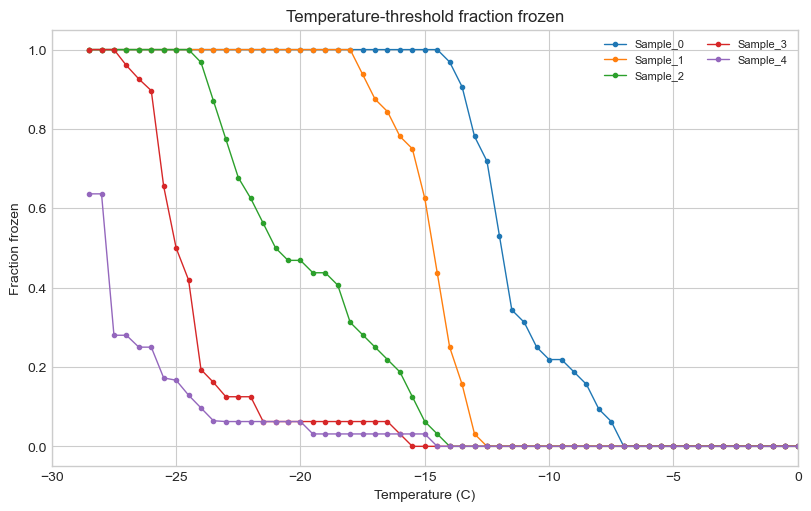

In [5]:
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

for sample_id, sample_df in fraction_df.groupby("sample_id", sort=False):
    ax.plot(
        sample_df["temperature_C"],
        sample_df["fraction_frozen"],
        marker="o",
        ms=3,
        lw=1.0,
        label=sample_id,
    )

ax.set(title="Temperature-threshold fraction frozen", xlabel="Temperature (C)", ylabel="Fraction frozen", xlim=TEMPERATURE_XLIM)
ax.legend(fontsize=8, ncols=2)
plt.show()

## Per-Dilution Spectra

These functions do not merge the dilution series. List in, list out.

In [6]:
per_dilution_suspension = ufolaf.cumulative_spec(fraction_tables)
per_dilution_air = ufolaf.normalize_spec(per_dilution_suspension)
per_dilution_air_df = ufolaf.tables_to_dataframe(per_dilution_air)
dilution_by_sample_id = sample_dilution_lookup(per_dilution_air)

print(f"Per-dilution air spectrum groups: {per_dilution_air_df['sample_id'].nunique()}")
display(per_dilution_air_df.head())

type(per_dilution_suspension[0])

Per-dilution air spectrum groups: 5


,sample_id,temperature_C,temperature_bin_width_C,temperature_bin_method,temperature_bin_left_C,temperature_bin_right_C,value,value_unit,lower_ci,upper_ci,qc_flag,basis
0,Sample_0,20.5,0.5,cold_threshold_max_tol_0.01C,20.5,21.0,-0.0,INP_per_L_air,0.0,0.001202,0,sampled_air
1,Sample_0,20.0,0.5,cold_threshold_max_tol_0.01C,20.0,20.5,-0.0,INP_per_L_air,0.0,0.001202,0,sampled_air
2,Sample_0,19.5,0.5,cold_threshold_max_tol_0.01C,19.5,20.0,-0.0,INP_per_L_air,0.0,0.001202,0,sampled_air
3,Sample_0,19.0,0.5,cold_threshold_max_tol_0.01C,19.0,19.5,-0.0,INP_per_L_air,0.0,0.001202,0,sampled_air
4,Sample_0,18.5,0.5,cold_threshold_max_tol_0.01C,18.5,19.0,-0.0,INP_per_L_air,0.0,0.001202,0,sampled_air


ufolaf_models.CumulativeNucleusSpectrumTable

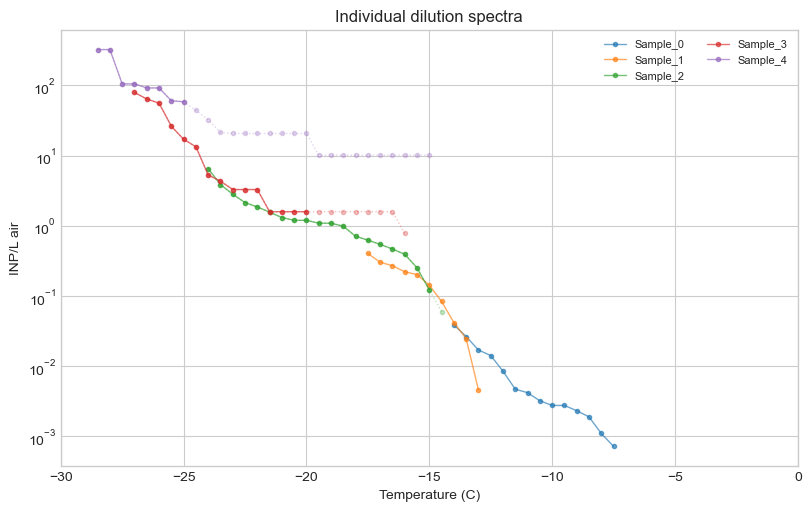

In [7]:
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

for sample_id, sample_df in per_dilution_air_df.groupby("sample_id", sort=False):
    plot_df = sample_df[np.isfinite(sample_df["value"]) & (sample_df["value"] > 0)]
    if plot_df.empty:
        continue
    plot_dilution_with_cutoff_style(
        ax,
        plot_df,
        sample_id=sample_id,
        dilution_by_sample_id=dilution_by_sample_id,
        marker="o",
        ms=3,
        lw=1.0,
        alpha=0.65,
        label=sample_id,
    )

ax.set_yscale("log")
ax.set(title="Individual dilution spectra", xlabel="Temperature (C)", ylabel="INP/L air", xlim=TEMPERATURE_XLIM)
ax.legend(fontsize=8, ncols=2)
plt.show()


## Merge Dilutions

These are the only steps here that merge a list of fraction-frozen tables into one spectrum. The MLE run below uses two explicit controls for high-dilution handling risk:

- `MLE_TEMPERATURE_ELIGIBILITY_C`: the warmest temperature where each dilution can contribute to MLE.
- `DILUTION_ACTION_COUNTS` plus `ACTION_WEIGHT_HALF_LIFE`: exponential likelihood discounting for extra dilution handling actions.


In [11]:
mle_control_df = pd.DataFrame({
    "dilution": list(DILUTION_LIKELIHOOD_WEIGHTS),
    "warmest_eligible_temperature_C": [
        MLE_TEMPERATURE_ELIGIBILITY_C[dilution]
        for dilution in DILUTION_LIKELIHOOD_WEIGHTS
    ],
    "action_count": [
        DILUTION_ACTION_COUNTS[dilution]
        for dilution in DILUTION_LIKELIHOOD_WEIGHTS
    ],
    "likelihood_weight": list(DILUTION_LIKELIHOOD_WEIGHTS.values()),
})
display(mle_control_df)

stitched_suspension = ufolaf.cumulative_spec_stitch(
    fraction_tables,
    enforce_monotone=ENFORCE_MONOTONE,
)
mle_suspension = ufolaf.cumulative_spec_mle(
    fraction_tables,
    enforce_monotone=ENFORCE_MONOTONE,
    temperature_eligibility_C=MLE_TEMPERATURE_ELIGIBILITY_C,
    dilution_action_counts=DILUTION_ACTION_COUNTS,
    action_weight_half_life=ACTION_WEIGHT_HALF_LIFE,
)

stitched_air = ufolaf.normalize_spec(stitched_suspension)
mle_air = ufolaf.normalize_spec(mle_suspension)

stitched_air_df = ufolaf.tables_to_dataframe(stitched_air)
mle_air_df = ufolaf.tables_to_dataframe(mle_air)

display(stitched_air_df.head())
display(mle_air_df.head())


,dilution,warmest_eligible_temperature_C,action_count,likelihood_weight
0,1,99.0,0,1.000000
1,13,-10.0,1,0.954842
2,169,-15.0,2,0.911722
3,2197,-20.0,3,0.870551
4,28561,-25.0,4,0.831238


,sample_id,temperature_C,temperature_bin_width_C,temperature_bin_method,temperature_bin_left_C,temperature_bin_right_C,value,value_unit,lower_ci,upper_ci,qc_flag,basis
0,CRG_M1,20.5,0.5,cold_threshold_max_tol_0.01C,20.5,21.0,-0.0,INP_per_L_air,0.0,0.001202,0,sampled_air
1,CRG_M1,20.0,0.5,cold_threshold_max_tol_0.01C,20.0,20.5,-0.0,INP_per_L_air,0.0,0.001202,0,sampled_air
2,CRG_M1,19.5,0.5,cold_threshold_max_tol_0.01C,19.5,20.0,-0.0,INP_per_L_air,0.0,0.001202,0,sampled_air
3,CRG_M1,19.0,0.5,cold_threshold_max_tol_0.01C,19.0,19.5,-0.0,INP_per_L_air,0.0,0.001202,0,sampled_air
4,CRG_M1,18.5,0.5,cold_threshold_max_tol_0.01C,18.5,19.0,-0.0,INP_per_L_air,0.0,0.001202,0,sampled_air


,sample_id,temperature_C,temperature_bin_width_C,temperature_bin_method,temperature_bin_left_C,temperature_bin_right_C,value,value_unit,lower_ci,upper_ci,qc_flag,basis
0,CRG_M1,20.5,0.5,cold_threshold_max_tol_0.01C,20.5,21.0,0.0,INP_per_L_air,0.0,0.000673,0,sampled_air
1,CRG_M1,20.0,0.5,cold_threshold_max_tol_0.01C,20.0,20.5,0.0,INP_per_L_air,0.0,0.000673,0,sampled_air
2,CRG_M1,19.5,0.5,cold_threshold_max_tol_0.01C,19.5,20.0,0.0,INP_per_L_air,0.0,0.000673,0,sampled_air
3,CRG_M1,19.0,0.5,cold_threshold_max_tol_0.01C,19.0,19.5,0.0,INP_per_L_air,0.0,0.000673,0,sampled_air
4,CRG_M1,18.5,0.5,cold_threshold_max_tol_0.01C,18.5,19.0,0.0,INP_per_L_air,0.0,0.000673,0,sampled_air


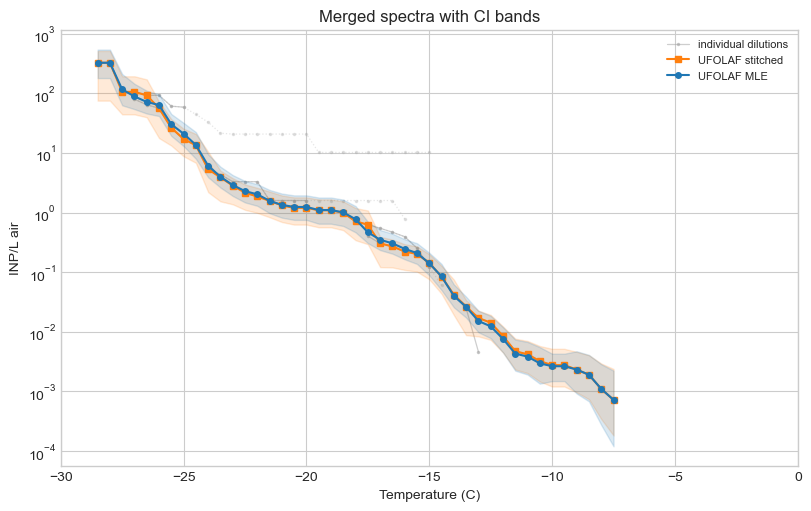

In [9]:
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

for sample_id, sample_df in per_dilution_air_df.groupby("sample_id", sort=False):
    plot_df = sample_df[np.isfinite(sample_df["value"]) & (sample_df["value"] > 0)].copy()
    if plot_df.empty:
        continue
    plot_dilution_with_cutoff_style(
        ax,
        plot_df,
        sample_id=sample_id,
        dilution_by_sample_id=dilution_by_sample_id,
        color="0.65",
        marker=".",
        ms=3,
        lw=0.9,
        alpha=0.55,
        zorder=1,
        label="individual dilutions" if sample_id == per_dilution_air_df["sample_id"].iloc[0] else None,
    )

for label, df, color, marker in (
    ("UFOLAF stitched", stitched_air_df, "tab:orange", "s"),
    ("UFOLAF MLE", mle_air_df, "tab:blue", "o"),
):
    plot_df = df[np.isfinite(df["value"]) & (df["value"] > 0)].copy()
    if plot_df.empty:
        continue
    ax.plot(plot_df["temperature_C"], plot_df["value"], marker=marker, ms=4, lw=1.5, color=color, label=label, zorder=3)
    if {"lower_ci", "upper_ci"}.issubset(plot_df.columns):
        lower = np.maximum(plot_df["value"] - plot_df["lower_ci"], np.nextafter(0, 1))
        upper = plot_df["value"] + plot_df["upper_ci"]
        ax.fill_between(plot_df["temperature_C"], lower, upper, color=color, alpha=0.16, zorder=2)

ax.set_yscale("log")
ax.set(title="Merged spectra with CI bands", xlabel="Temperature (C)", ylabel="INP/L air", xlim=TEMPERATURE_XLIM)
ax.legend(fontsize=8)
plt.show()

## Optional OLAF Final CSV Comparison

This only reads the final OLAF `INPs_L` CSV for visual comparison.

,site,start_time,end_time,filter_color,sample_type,vol_air_filt,proportion_filter_used,vol_susp,treatment,notes,user,IS
0,CRG_M1,2025-08-12 13:00:00,2025-08-13 13:00:00,white,air,17829.1,1.0,10,base,none,Carson,IS1a


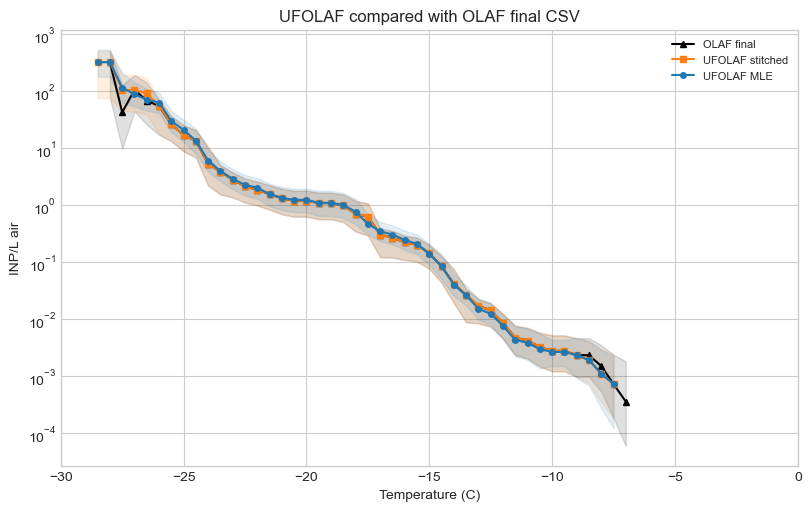

In [10]:
def read_olaf_inps_l_reference(path):
    metadata = {}
    header_row_index = None
    with Path(path).open("r", encoding="utf-8") as handle:
        for line_index, line in enumerate(handle):
            stripped = line.strip()
            if stripped.startswith("degC,"):
                header_row_index = line_index
                break
            if "=" in stripped:
                key, value = stripped.split("=", 1)
                metadata[key.strip()] = value.strip()
    if header_row_index is None:
        raise ValueError("OLAF INPs_L file is missing the degC,dilution,INPS_L header")

    source_df = pd.read_csv(path, skiprows=header_row_index)
    return pd.DataFrame(
        {
            "sample_id": metadata.get("site", "OLAF"),
            "temperature_C": pd.to_numeric(source_df["degC"], errors="coerce"),
            "dilution": pd.to_numeric(source_df["dilution"], errors="coerce"),
            "value": pd.to_numeric(source_df["INPS_L"], errors="coerce"),
            "lower_ci": pd.to_numeric(source_df["lower_CI"], errors="coerce"),
            "upper_ci": pd.to_numeric(source_df["upper_CI"], errors="coerce"),
        }
    ), metadata


if OLAF_REFERENCE_PATH.exists():
    olaf_df, olaf_metadata = read_olaf_inps_l_reference(OLAF_REFERENCE_PATH)
    display(pd.DataFrame([olaf_metadata]))

    fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
    for label, df, color, marker in (
        ("OLAF final", olaf_df, "black", "^"),
        ("UFOLAF stitched", stitched_air_df, "tab:orange", "s"),
        ("UFOLAF MLE", mle_air_df, "tab:blue", "o"),
    ):
        plot_df = df[np.isfinite(df["value"]) & (df["value"] > 0)].copy()
        if plot_df.empty:
            continue
        ax.plot(plot_df["temperature_C"], plot_df["value"], marker=marker, ms=4, lw=1.5, color=color, label=label)
        if {"lower_ci", "upper_ci"}.issubset(plot_df.columns):
            lower = np.maximum(plot_df["value"] - plot_df["lower_ci"], np.nextafter(0, 1))
            upper = plot_df["value"] + plot_df["upper_ci"]
            ax.fill_between(plot_df["temperature_C"], lower, upper, color=color, alpha=0.12)

    ax.set_yscale("log")
    ax.set(title="UFOLAF compared with OLAF final CSV", xlabel="Temperature (C)", ylabel="INP/L air", xlim=TEMPERATURE_XLIM)
    ax.legend(fontsize=8)
    plt.show()
else:
    print(f"OLAF reference CSV not found: {OLAF_REFERENCE_PATH}")